In [17]:
import math
import matplotlib.pyplot as plt
import numpy as np
from pyquasoare import approx, models

# Structure of the GR2M rainfall-runoff model
The [GR2M](https://webgr.inrae.fr/eng/tools/hydrological-models/monthly-hydrological-model-gr2m) is a monthly rainfall-runoff model that is used to simulate rainfall-runoff relationship at the catchment scale. It is characterised by a very parsomonious structure that only requires the definition of two parameters defined below. The model possesses two internal stores as shown in the image below. 

![GR2M Model](gr2m_model.png)

The first store is named "production store" and is characterised by the following ODE following [Mouelhi et al.](https://www.sciencedirect.com/science/article/pii/S0022169405003033):
$$
\frac{dx}{dt} = \frac{P}{X_1} (1 - x^2) - \frac{E_0}{X_1}\ x\ (2 - x) -\frac{1}{\Delta} x^{4/3}
$$
with $x = S/X_1$ \[-\] the store level, $X_1$ \[mm\] the store capacity (the first GR2M parameter), $P$ the monthly rainfall \[mm/mth\], $E_0$ \[mm/mth\] the potential evapotranspiration and $\Delta$ \[mth\] is the timestep duration (=1). The effective rainfall generated by this store is defined as follows:
$$
    P_{eff} = P\ x^2 + \frac{X_1}{\Delta}\ x^{4/3}
$$

The second store is named "routing store" and is characterised by the following equation:
$$
\frac{dy}{dt} = \frac{P_{eff}}{X_3} + \frac{X_2}{X_3}\ y - \frac{1}{\Delta} y^2
$$
where $y = R / X_3$ \[-\] the store level, $X_3$ \[mm\] is the store capacity set to 60mm, $X_2$ \[mm/mth\] is the rate of inter-catchment exchange (see [Mouelhi et al.](https://www.sciencedirect.com/science/article/pii/S0022169405003033)). The simulated discharge 

# Resolution of the model using the QuaSoARe solver
The flux functions from the two reservoirs are first approximated by piecewise-quadratic function via the [approx.quad_coefficient_matrix](https://github.com/csiro-hydroinformatics/pyquasoare/blob/e513eeaa10b3875f83d671806c0cb1783b0d36fd/src/pyquasoare/approx.py#L267) function in the pyquasoare package. These functions are defined up to a multiplicative constant that will be defined later as "flux scalings".

The production store requires the definition of three flux functions: 
* $f_1(x) = 1 - x^2$
* $f_2(x) = - x\ (2 - x)$
* $f_3(x) = - x^{4/3}$

We approximate these functions using 10 nodes between $x=0$ and $x=1$ as follows:

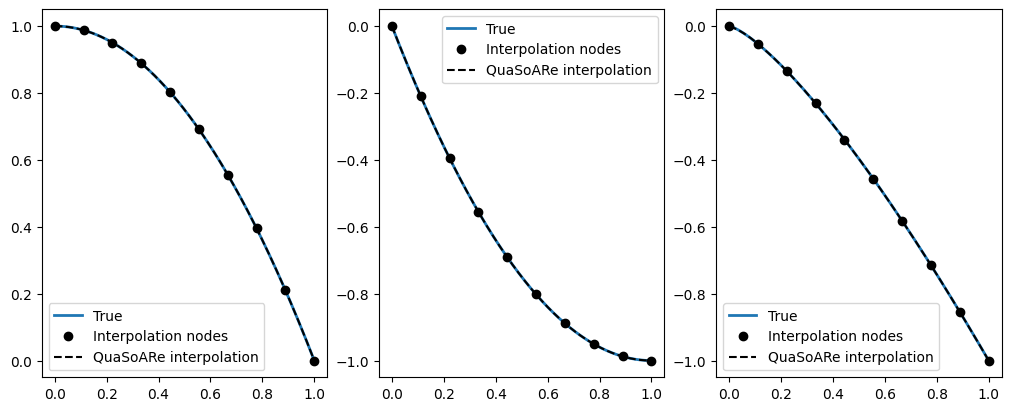

In [18]:
def f1(x):
    return 1 - x**2
    
def f2(x):
    return - x * (2 - x)

def f3(x):
    return -x**(4./3.)

alphas = np.linspace(0, 1, 10)
prod_coefs = approx.quad_coefficient_matrix([f1, f2, f3], alphas)

xx = np.linspace(0, 1, 500)
fint = approx.quad_fun_from_matrix(alphas, prod_coefs, xx)
fig, axs = plt.subplots(ncols=3, figsize=(10, 4), layout="constrained")
for ifx in range(3):
    ax = axs[ifx]
    fx = [f1, f2, f3][ifx]
    ax.plot(xx, fx(xx), label="True", lw=2)
    ax.plot(alphas, fx(alphas), "ko", label="Interpolation nodes")
    ax.plot(xx, fint[:, ifx], "k--", label="QuaSoARe interpolation")
    ax.legend()


We now repeat the process for the flux functions corresponding to the routing store:
* $g_1(x) = 1$
* $g_2(x) = x$
* $g_3(x) = - x^2$


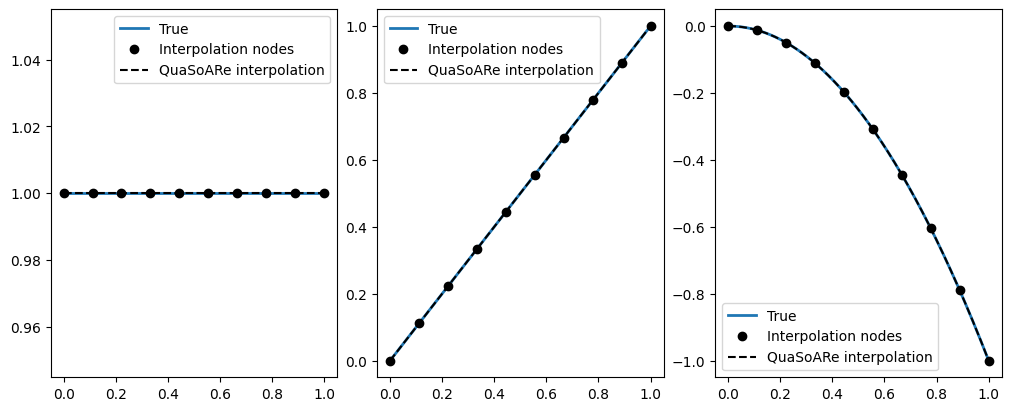

In [19]:
def g1(x):
    return np.ones_like(x)
    
def g2(x):
    return x

def g3(x):
    return -x**2

alphas = np.linspace(0, 1, 10)
route_coefs = approx.quad_coefficient_matrix([g1, g2, g3], alphas)

xx = np.linspace(0, 1, 500)
fint = approx.quad_fun_from_matrix(alphas, route_coefs, xx)
fig, axs = plt.subplots(ncols=3, figsize=(10, 4), layout="constrained")
for ifx in range(3):
    ax = axs[ifx]
    fx = [g1, g2, g3][ifx]
    ax.plot(xx, fx(xx), label="True", lw=2)
    ax.plot(alphas, fx(alphas), "ko", label="Interpolation nodes")
    ax.plot(xx, fint[:, ifx], "k--", label="QuaSoARe interpolation")
    ax.legend()


# Run the solver with given inputs
Once the interpolation of the flux function is completed, we can run the QuaSoARe solver with a series of inputs. 
As indicated above, the flux functions were defined up to a multiplicative constant. These constant can be defined for each timestep and are named "scalings". Running the QuaSoARe solver using timeseries inputs is done via the ["models.quad_model"](https://github.com/csiro-hydroinformatics/pyquasoare/blob/e513eeaa10b3875f83d671806c0cb1783b0d36fd/src/pyquasoare/models.py#L14) function. 

The three flux scalings for the production stores are as follows:
* $\eta_1 = P / X_1$ (corresponding to flux function $f_1$)
* $\eta_2 = E_0 / X_1$ (corresponding to flux function $f_2$)
* $\eta_3 = 1 / \Delta$ (corresponding to flux function $f_3$)

For the routing store, we have:
* $\mu_1 = P_{eff} / X_3$ (corresponding to flux function $g_1$)
* $\mu_2 = X_2 /X_3 $ (corresponding to flux function $g_2$)
* $\mu_3 = 1 / \Delta$ (corresponding to flux function $g_3$)


In [22]:
# Timestep (one month)
Delta = 1

# Random rainfall and PET timeseries
nval = 100
P = np.exp(np.random.uniform(-4, 4, size=nval))
k = np.arange(nval)
E0 = 200 * (1 + np.cos(k * 2 * math.pi / 12)) / 2
    
# We run the solver for a given parameters
X1 = 400
X2 = -10
X3 = 60
x0 = 0.

# Define flux scalings
prod_scalings = np.ones((nval, 3))
prod_scalings[:, 0] = P / X1
prod_scalings[:, 1] = E0 / X1
prod_scalings[:, 2] = 1 / Delta

route_scalings = np.ones((nval, 3))
# .. first scaling is defined by Peff, which needs the solution of the production store
route_scalings[:, 1] = X2 / X3
route_scalings[:, 2] = 1 / Delta

# Solve production store
_, _, prod_fluxes = models.quad_model(alphas, prod_scalings, prod_coefs, x0, Delta)

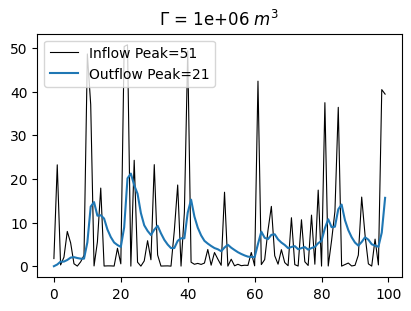

In [19]:
fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
time = np.arange(nval)

ax.plot(time, Qstars, "k-", lw=0.8, label=f"Inflow Peak={Qstars.max():0.0f}")
qout = -fluxes[:, 1] * Gamma / Delta
ax.plot(time, qout, label=f"Outflow Peak={qout.max():0.0f}")
ax.set(title=f"$\\Gamma$ = {Gamma:0.0e} $m^3$")
ax.legend(loc=2)

# Testing different parameters
We can easily compare the solution obtained with different values for parameters $\Gamma$ (capacity) and $\nu$ (power exponent).

In [20]:
# define a parameterised solution function
def solve(x0, Gamma, nu):
    # 1. approximate flux functions
    coefs = approx.quad_coefficient_matrix([f1, f2], alphas)

    # 2. define flux scalings
    scalings = np.ones((nval, 2))
    scalings[:, 0] = Qstars / Gamma
    scalings[:, 1] = 1 / Delta
    
    # Solve
    _, x, fluxes = models.quad_model(alphas, scalings, coefs, x0, Delta)
    return -fluxes[:, 1] * Gamma / Delta

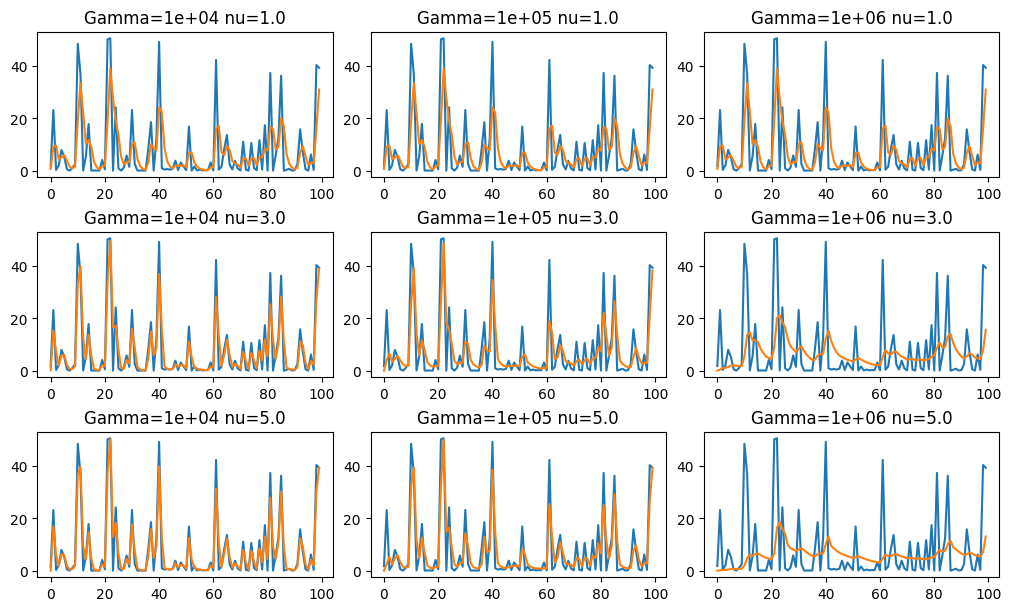

In [21]:
Gammas = [1e4, 1e5, 1e6]
nus = [1., 3., 5.]
mosaic = [[f"{g}/{n}" for g in Gammas] for n in nus]
fig = plt.figure(figsize=(10, 6), layout="constrained")
axs = fig.subplot_mosaic(mosaic)
x0 = 0.
for aname, ax in axs.items():
    Gamma, nu = [float(v) for v in aname.split("/")]
    qout = solve(x0, Gamma, nu)
    ax.plot(time, Qstars)
    ax.plot(time, qout)
    ax.set(title=f"Gamma={Gamma:0.0e} nu={nu:0.1f}")

The solution for increasing reservoir capacity demonstrates how flood routing progressively attenuates the flood peak for larger stored volumes.